In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from lightgbm import LGBMRegressor
from math import radians, sin, cos, sqrt, atan2
import os
# 自动创建图表存储文件夹，不存在则新建
CHART_DIR = "./charts"
os.makedirs(CHART_DIR, exist_ok=True)
# 统一matplotlib全局配置：中文显示、高清保存
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号乱码
plt.rcParams["savefig.dpi"] = 300  # 高清图片
plt.rcParams["figure.dpi"] = 100

In [4]:
# 读取数据集
df = pd.read_csv('D:/GitHub/NYC-Taxi-Trip-Duration-Analysis-main/data/data_encoded.csv')
# 查看数据的前5行
df.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,log_trip_duration,hour,day_of_week,month,haversine_distance,manhattan_distance,euclidean_distance,lat_diff,lon_diff
0,2,1,-73.985611,40.735943,-73.980331,40.760468,6.947937,7,2,6,2.763050,0.029804,0.025087,0.024525,0.005280
1,2,1,-73.978394,40.764351,-73.991623,40.749859,6.719013,12,6,4,1.959178,0.027721,0.019622,0.014492,0.013229
2,2,5,-73.989059,40.744389,-73.973381,40.748692,6.421622,2,6,6,1.404772,0.019981,0.016258,0.004303,0.015678
3,2,2,-73.990326,40.731136,-73.991264,40.748917,6.766192,17,3,5,1.978660,0.018719,0.017805,0.017780,0.000938
4,1,4,-73.789497,40.646675,-73.987137,40.759232,7.651358,17,3,5,7.823950,0.101954,0.077125,0.055935,0.050800


In [5]:
# 查看字段类型、非空数量
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   vendor_id           100000 non-null  int64  
 1   passenger_count     100000 non-null  int64  
 2   pickup_longitude    100000 non-null  float64
 3   pickup_latitude     100000 non-null  float64
 4   dropoff_longitude   100000 non-null  float64
 5   dropoff_latitude    100000 non-null  float64
 6   log_trip_duration   100000 non-null  float64
 7   hour                100000 non-null  int64  
 8   day_of_week         100000 non-null  int64  
 9   month               100000 non-null  int64  
 10  haversine_distance  100000 non-null  float64
 11  manhattan_distance  100000 non-null  float64
 12  euclidean_distance  100000 non-null  float64
 13  lat_diff            100000 non-null  float64
 14  lon_diff            100000 non-null  float64
dtypes: float64(10), int64(5)
memory usa

In [6]:
# 打印乘客数异常订单数量
# 统计乘客数等于0的订单条数
print("0乘客订单数：", len(df[df['passenger_count'] == 0]))
# 统计乘客数大于6的订单条数
print("超过6人订单数：", len(df[df['passenger_count'] > 6]))
# 以乘客数举例计算IQR阈值
# 下四分位数：25%分位点
Q1 = df['passenger_count'].quantile(0.25)
# 上四分位数：75%分位点
Q3 = df['passenger_count'].quantile(0.75)
# 四分位距 = 上四分位数 - 下四分位数
IQR = Q3 - Q1
# 异常下限：低于此值判定为极小值异常
lower_bound = Q1 - 1.5 * IQR
# 异常上限：高于此值判定为极大值异常
upper_bound = Q3 + 1.5 * IQR
# 格式化打印乘客数正常数值区间，取整数展示
print(f"乘客数正常区间：{lower_bound:.0f} ~ {upper_bound:.0f}")

# 设置pandas全局浮点数显示格式，保留2位小数，消除科学计数法
pd.set_option('display.float_format', lambda x: '%.2f' % x)
# 输出描述性统计表，数值展示更直观易读
df.describe()

0乘客订单数： 4
超过6人订单数： 0
乘客数正常区间：-0 ~ 4


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,log_trip_duration,hour,day_of_week,month,haversine_distance,manhattan_distance,euclidean_distance,lat_diff,lon_diff
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,1.54,1.67,-73.97,40.75,-73.97,40.75,6.45,13.60,3.05,3.52,2.90,0.04,0.03,0.02,0.02
std,0.50,1.32,0.04,0.03,0.04,0.04,0.75,6.39,1.95,1.68,2.24,0.03,0.02,0.02,0.02
min,1.00,0.00,-77.90,35.31,-79.82,35.17,1.10,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,1.00,-73.99,40.74,-73.99,40.74,5.98,9.00,1.00,2.00,1.23,0.02,0.01,0.01,0.01
50%,2.00,1.00,-73.98,40.75,-73.98,40.75,6.50,14.00,3.00,4.00,2.09,0.03,0.02,0.01,0.01
75%,2.00,2.00,-73.97,40.77,-73.96,40.77,6.98,19.00,5.00,5.00,3.87,0.05,0.04,0.03,0.02
max,2.00,6.00,-72.07,41.03,-72.02,41.20,7.65,23.00,6.00,6.00,7.82,0.10,0.08,0.06,0.05


In [7]:
# 检查数据集每一列的缺失值数量
print("===== 各字段缺失样本绝对数量 =====")
print(df.isnull().sum())
# 计算每一列缺失值占全部样本的百分比，直观判断缺失严重程度
missing_percent = (df.isnull().sum() / len(df) * 100).round(3)
print("各字段缺失值占比(%)：")
print(missing_percent)

# 条件判断：如果存在缺失值才打印提示，自动化校验
if df.isnull().sum().sum() > 0:
    print("数据存在缺失值，需要进行填充/删除处理")
else:
    print("✅ 数据集无缺失值，无需缺失处理步骤")

===== 各字段缺失样本绝对数量 =====
vendor_id             0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
log_trip_duration     0
hour                  0
day_of_week           0
month                 0
haversine_distance    0
manhattan_distance    0
euclidean_distance    0
lat_diff              0
lon_diff              0
dtype: int64
各字段缺失值占比(%)：
vendor_id            0.00
passenger_count      0.00
pickup_longitude     0.00
pickup_latitude      0.00
dropoff_longitude    0.00
dropoff_latitude     0.00
log_trip_duration    0.00
hour                 0.00
day_of_week          0.00
month                0.00
haversine_distance   0.00
manhattan_distance   0.00
euclidean_distance   0.00
lat_diff             0.00
lon_diff             0.00
dtype: float64
✅ 数据集无缺失值，无需缺失处理步骤


In [8]:
# 检测数据集中完全重复的样本行，并统计重复总行数
dup_count = df.duplicated().sum()
print(f"数据集重复行总数量：{dup_count}")

# 自动化判断，输出校验结论
if dup_count > 0:
    print("⚠️ 存在重复样本，需执行删除重复行操作")
    # 查看前5条重复数据，用于人工核验
    print("前5条重复样本详情：")
    print(df[df.duplicated()].head())
else:
    print("✅ 数据集无完全重复样本，无需去重处理")

数据集重复行总数量：0
✅ 数据集无完全重复样本，无需去重处理


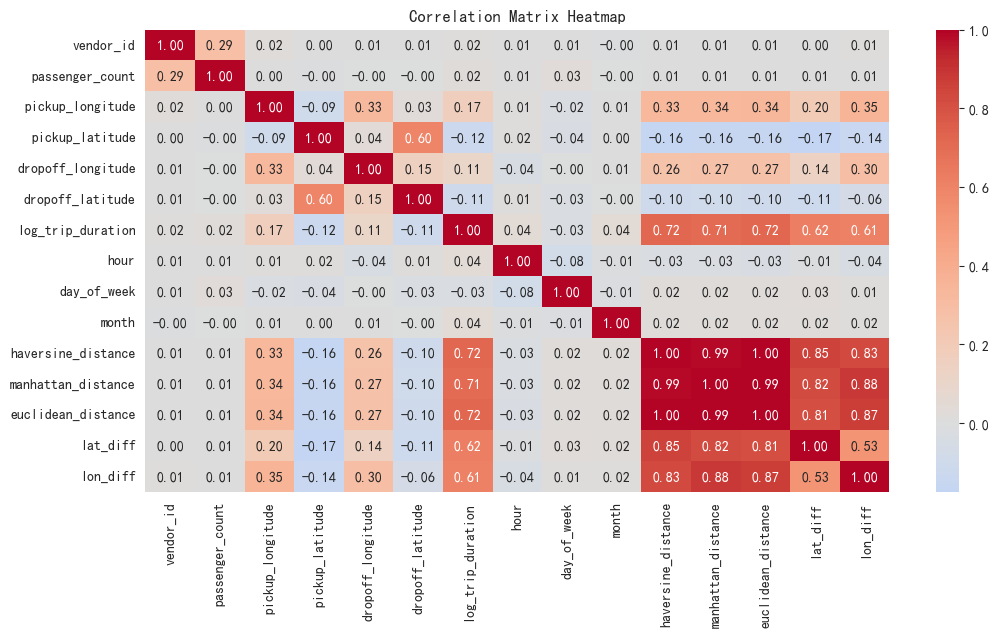

特征与行程时长相关性排序：
log_trip_duration    1.00
euclidean_distance   0.72
haversine_distance   0.72
manhattan_distance   0.71
lat_diff             0.62
lon_diff             0.61
pickup_longitude     0.17
pickup_latitude      0.12
dropoff_longitude    0.11
dropoff_latitude     0.11
month                0.04
hour                 0.04
day_of_week          0.03
passenger_count      0.02
vendor_id            0.02
Name: log_trip_duration, dtype: float64

高共线性特征对（系数>0.8）：
('haversine_distance', 'manhattan_distance', 0.9896509711423195)
('haversine_distance', 'euclidean_distance', 0.9950557875455227)
('haversine_distance', 'lat_diff', 0.8511123300527087)
('haversine_distance', 'lon_diff', 0.8268536504189147)
('manhattan_distance', 'euclidean_distance', 0.9942448976726368)
('manhattan_distance', 'lat_diff', 0.8195881021274721)
('manhattan_distance', 'lon_diff', 0.8837724200473936)
('euclidean_distance', 'lat_diff', 0.8137974278548294)
('euclidean_distance', 'lon_diff', 0.8714054470572162)


In [9]:
# 绘制特征相关性热力图，分析数值特征间线性相关强弱
# 选择数值型特征进行相关性热力图绘制
# 设置画布尺寸：宽12英寸，高6英寸
plt.figure(figsize=(12, 6))
# 自动筛选所有数值型(int/float)特征，生成列表
numerical_cols = df.select_dtypes(include="number").columns.tolist()

# 计算相关性矩阵
corr = df[numerical_cols].corr()

# 绘制热力图
# cmap="coolwarm" 冷暖配色：红色正相关，蓝色负相关
# annot=True 在格子内显示相关系数数值
# fmt=".2f" 系数保留2位小数
# center=0 以0为配色分界点，正负相关颜色区分对称
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", center=0)
plt.title("Correlation Matrix Heatmap")
plt.savefig(os.path.join(CHART_DIR, "correlation_heatmap.png"), bbox_inches="tight")
plt.show()
plt.show()

# 筛选与目标标签log_trip_duration相关性绝对值大于0.5的特征，筛选强关联特征
# 取出目标变量和所有特征的相关系数，取绝对值后从高到低排序
target_corr = corr["log_trip_duration"].abs().sort_values(ascending=False)
print("特征与行程时长相关性排序：")
print(target_corr)

# 找出多重共线性特征（相关系数>0.8）
high_corr_pairs = []
threshold = 0.8
# 双重循环遍历相关矩阵上下三角（只遍历右上，避免重复配对）
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        # 判断两个特征相关系数绝对值是否超过阈值
        if abs(corr.iloc[i,j]) > threshold:
            # 存入三元组：特征1、特征2、相关系数
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))
print("\n高共线性特征对（系数>0.8）：")
for pair in high_corr_pairs:
    print(pair)

In [19]:
# Feature Engineering, create distance and time features
# 1. 目标标签对数变换 Log1p transformation of trip_duration
# np.log1p(x) = ln(x + 1)，专门处理右偏长尾的行程时长数据，同时避免x=0时报ln(0)无穷错误
df['log_trip_duration'] = np.log1p(df['trip_duration'])

# 2. 时间衍生特征 Time features
# 将字符串格式的上车时间，转换为Python标准datetime时间格式，才能提取时分日月
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
# 提取上车小时（0~23），早晚7-9、17-20点拥堵，是核心时序特征
df['hour'] = df['pickup_datetime'].dt.hour
# 提取星期，0=周一，6=周日，区分工作日通勤拥堵/周末休闲出行
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
# 提取月份，区分冬季雨雪、夏季路况差异
df['month'] = df['pickup_datetime'].dt.month

# 3. 地理距离特征 Distance features
# 自定义哈弗辛公式函数：根据经纬度计算地球球面真实地表距离（单位km）
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # 地球平均半径，单位：千米km
    # 纬度差值转为弧度
    dlat = radians(lat2 - lat1)
    # 经度差值转为弧度
    dlon = radians(lon2 - lon1)
    # 哈弗辛核心计算公式
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    # 最终返回两点地表直线距离
    return R * c

# 计算每单上下车点的球面大圆距离（项目最核心预测特征）
# axis=1 代表按行遍历整张表格，每行传入上下车经纬度调用haversine函数
df['haversine_distance'] = df.apply(
    lambda row: haversine(row['pickup_latitude'], row['pickup_longitude'],
                         row['dropoff_latitude'], row['dropoff_longitude']),
    axis=1
)

# 曼哈顿距离：模拟城市横平竖直街道，南北偏移+东西偏移总和，近似道路行驶里程
df['manhattan_distance'] = abs(df['pickup_latitude'] - df['dropoff_latitude']) + \
                           abs(df['pickup_longitude'] - df['dropoff_longitude'])

# 欧式平面直线距离：平面几何两点直线距离，不考虑地球球面曲率
df['euclidean_distance'] = np.sqrt((df['pickup_latitude'] - df['dropoff_latitude'])**2 + \
                                   (df['pickup_longitude'] - df['dropoff_longitude'])**2)

# 单独纬度、经度差值特征，补充南北/东西行驶方向信息
df['lat_diff'] = abs(df['pickup_latitude'] - df['dropoff_latitude'])
df['lon_diff'] = abs(df['pickup_longitude'] - df['dropoff_longitude'])

# 业务衍生车速特征 Speed Features for haversine_distance
# 平均时速(km/h) = 球面距离km / (总秒数 ÷ 3600)  秒转小时
df['avg_speed_kmh'] = df['haversine_distance'] / (df['trip_duration'] / 3600)
# 原地上下车时距离=0，除法会生成无穷大inf值，统一替换为空值NaN
df['avg_speed_kmh'] = df['avg_speed_kmh'].replace([np.inf, -np.inf], np.nan)
# 删除车速为空的异常订单，清洗无效样本
df = df.dropna(subset=['avg_speed_kmh'])

df.head()

KeyError: 'trip_duration'

In [21]:
# Making a sample of the data
# We create two copies of the sample for different purposes:
# df_outlier: 用于异常值分析、可视化绘图，完整保留全部离群样本不做删除
# df_model: 后续经过异常值清洗、过滤干净后，专门用来训练模型

# 随机抽取10万条数据子集，random_state=42固定随机种子，保证每次抽样结果完全一致，实验可复现
df_sample = df.sample(100_000, random_state=42)
# 深拷贝第一份数据副本：专门留存原始样本，用于异常探索分析
df_outlier = df_sample.copy()
# 深拷贝第二份独立副本：后续会删除异常、清洗脏数据，作为建模专用数据集
df_model = df_sample.copy()
df_outlier.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,log_trip_duration,hour,day_of_week,month,haversine_distance,manhattan_distance,euclidean_distance,lat_diff,lon_diff
75721,1,1,-73.97,40.78,-73.98,40.78,5.00,8,1,2,0.86,0.01,0.01,0.01,0.01
80184,1,1,-73.99,40.72,-74.00,40.72,5.87,23,4,2,1.21,0.02,0.01,0.01,0.01
19864,1,2,-73.97,40.79,-73.98,40.76,6.49,21,3,6,2.94,0.03,0.03,0.03,0.00
76699,2,5,-73.99,40.74,-73.98,40.75,6.53,18,1,1,1.29,0.02,0.01,0.01,0.01
92991,2,2,-73.94,40.82,-73.95,40.79,6.61,8,2,4,3.22,0.04,0.03,0.03,0.02


In [22]:
# 数值特征标准化，适配孤立森林异常检测模型 Scale the data
# 初始化鲁棒标准化器：基于四分位数缩放，对极端异常值不敏感，比StandardScaler更适合带离群点的数据
scaler = RobustScaler()
# 仅对全部数值列做训练+转换，输出标准化后的二维数组
scaler_data = scaler.fit_transform(df_outlier[numerical_cols])

# Detect outliers with Isolation Forest
# Outliers are detected using Isolation Forest on scaled numerical features
# 初始化孤立森林：contamination=0.01 代表数据中预计存在1%异常样本，固定随机种子保证复现
iso = IsolationForest(contamination=0.01, random_state=42)
# fit_predict：训练模型并预测，返回1=正常样本，-1=异常样本
# 判断==-1，生成布尔掩码：True代表该行是异常，False为正常
outliers_mask = iso.fit_predict(scaler_data) == -1
# 拷贝一份独立副本，避免修改原始df_outlier
df_outlier = df_outlier.copy()
# 新增一列标记，True=异常样本，False=正常样本
df_outlier['is_outlier'] = outliers_mask
# 统计并打印检测出的异常样本总数
print(f"Number of outliers detected: {np.sum(outliers_mask)}")
df_outlier.head()

Number of outliers detected: 1000


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,log_trip_duration,hour,day_of_week,month,haversine_distance,manhattan_distance,euclidean_distance,lat_diff,lon_diff,is_outlier
75721,1,1,-73.97,40.78,-73.98,40.78,5.00,8,1,2,0.86,0.01,0.01,0.01,0.01,False
80184,1,1,-73.99,40.72,-74.00,40.72,5.87,23,4,2,1.21,0.02,0.01,0.01,0.01,False
19864,1,2,-73.97,40.79,-73.98,40.76,6.49,21,3,6,2.94,0.03,0.03,0.03,0.00,False
76699,2,5,-73.99,40.74,-73.98,40.75,6.53,18,1,1,1.29,0.02,0.01,0.01,0.01,False
92991,2,2,-73.94,40.82,-73.95,40.79,6.61,8,2,4,3.22,0.04,0.03,0.03,0.02,False


KeyError: 'avg_speed_kmh'

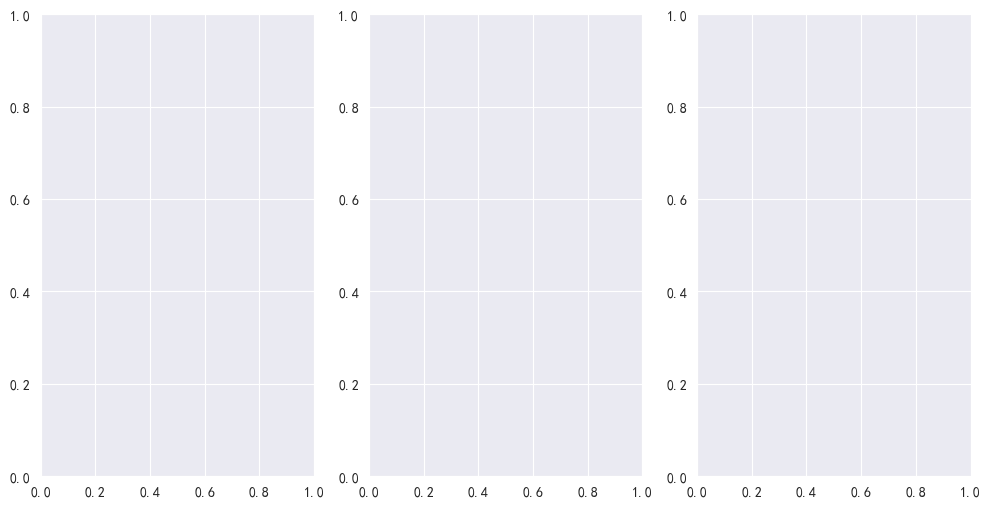

In [23]:
# Scatter plots to visualize outliers in distance features
# Scatter plots show distance vs average speed to visualize detected outliers
# Note: Overlaps may appear because Isolation Forest identifies subtle outliers that may still lie close to normal points
distance_cols = ['haversine_distance', 'manhattan_distance', 'euclidean_distance']

# Create 3 plots horizontally
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

for idx, col in enumerate(distance_cols):
    ax = axes[idx]
    
    # Normal points
    ax.scatter(
        df_outlier.loc[~df_outlier['is_outlier'], col],
        df_outlier.loc[~df_outlier['is_outlier'], 'avg_speed_kmh'],
        label='Normal',
        s=15,
        alpha=0.5,
        color='steelblue',
        edgecolors='none'
    )
    
    # Outlier points
    ax.scatter(
        df_outlier.loc[df_outlier['is_outlier'], col],
        df_outlier.loc[df_outlier['is_outlier'], 'avg_speed_kmh'],
        label='Outliers',
        s=30,
        color='red',
        alpha=0.7,
        marker='D',
        edgecolors='darkred',
        linewidth=0.5
    )
    
    ax.set_xlabel(f'{col} (km)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Average Speed (km/h)', fontsize=11, fontweight='bold')
    ax.set_title(f'Isolation Forest: {col}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Outliers Detection by Distance Metrics', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "isolation_outlier_scatter.png"), bbox_inches="tight")
plt.show()

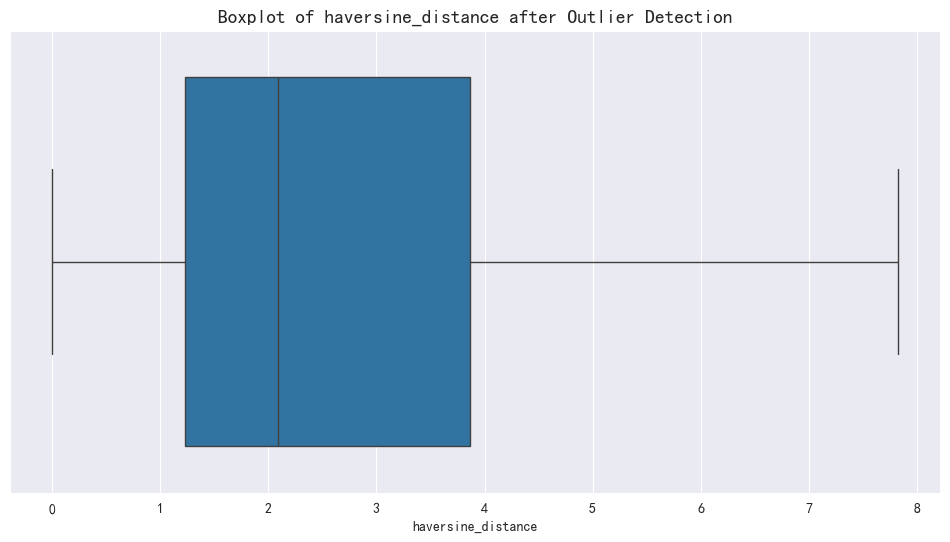

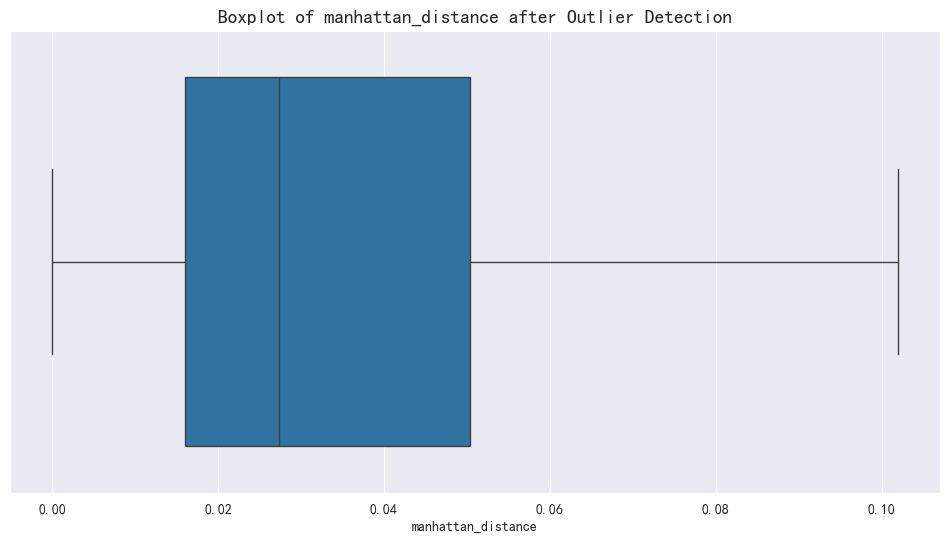

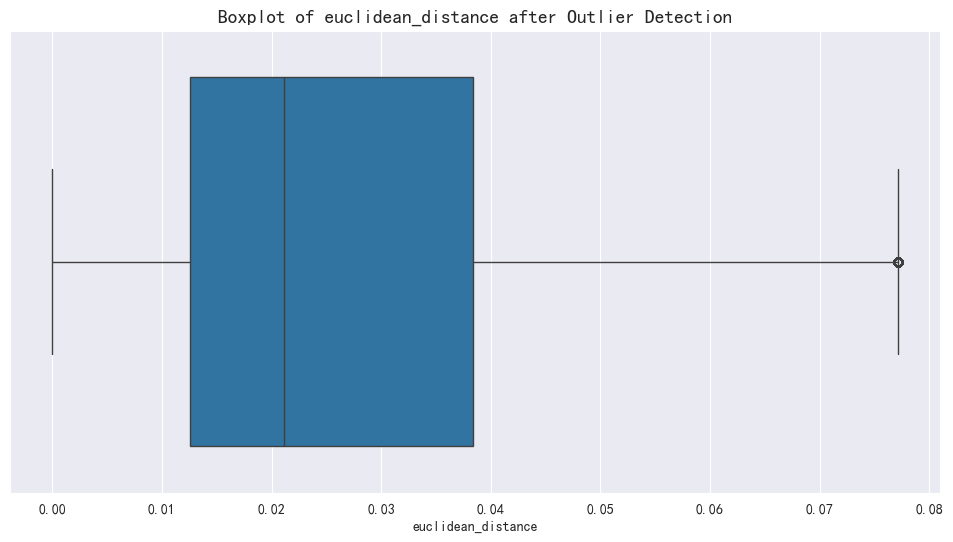

In [28]:
# Boxplots to visualize outliers in distance features
# 箱线图：可视化三类距离特征的数值分布与离群点
distance_cols = ['haversine_distance', 'manhattan_distance', 'euclidean_distance']
# 循环遍历三种距离，分别绘制独立箱线图
for col in distance_cols:
    # 设定单张画布尺寸
    plt.figure(figsize=(12, 6))
    # 绘制箱线图，X轴为当前距离特征全部样本
    sns.boxplot(x=df_outlier[col])
    # 设置图表标题
    plt.title(f'Boxplot of {col} after Outlier Detection', fontsize=14, fontweight='bold')
    plt.savefig(os.path.join(CHART_DIR, f"boxplot_{col}.png"), bbox_inches="tight")
    plt.show()

In [24]:
# Handling outliers with Capping method
# 定义IQR上下限截断函数：缩尾处理，不删除样本，只把极端值限制在四分位边界
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    Lower_bound = Q1 - 1.5 * IQR
    Upper_bound = Q3 + 1.5 * IQR
    return series.clip(lower = Lower_bound, upper = Upper_bound)

# 需要做截断处理的数值特征清单
cap_columns = [
    'trip_duration',
    'haversine_distance',
    'manhattan_distance',
    'euclidean_distance',
    'lat_diff',
    'lon_diff',
    'avg_speed_kmh'
]

# 循环对df_outlier（分析集）、df_model（建模集）同步做缩尾
for col in cap_columns:
    df_outlier[col] = cap_outliers(df_outlier[col])
    df_model[col] = cap_outliers(df_model[col])

# 截断时长后，重新计算对数标签，保证标签和原始时长同步更新
df_outlier['log_trip_duration'] = np.log1p(df_outlier['trip_duration'])
df_model['log_trip_duration'] = np.log1p(df_model['trip_duration'])

# Verify no outliers remain
# Boxplots after capping outliers
# 绘图验证：截断后箱线外侧不再存在离群散点
# Boxplots are created using df_outlier to highlight and explore outliers for analysis purposes
for col in cap_columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=df_outlier[col])
    plt.title(f'Boxplot of {col} after Capping Outliers')
    plt.savefig(os.path.join(CHART_DIR, f"boxplot_capped_{col}.png"), bbox_inches="tight")
    plt.show()

KeyError: 'trip_duration'

KeyError: 'trip_duration'

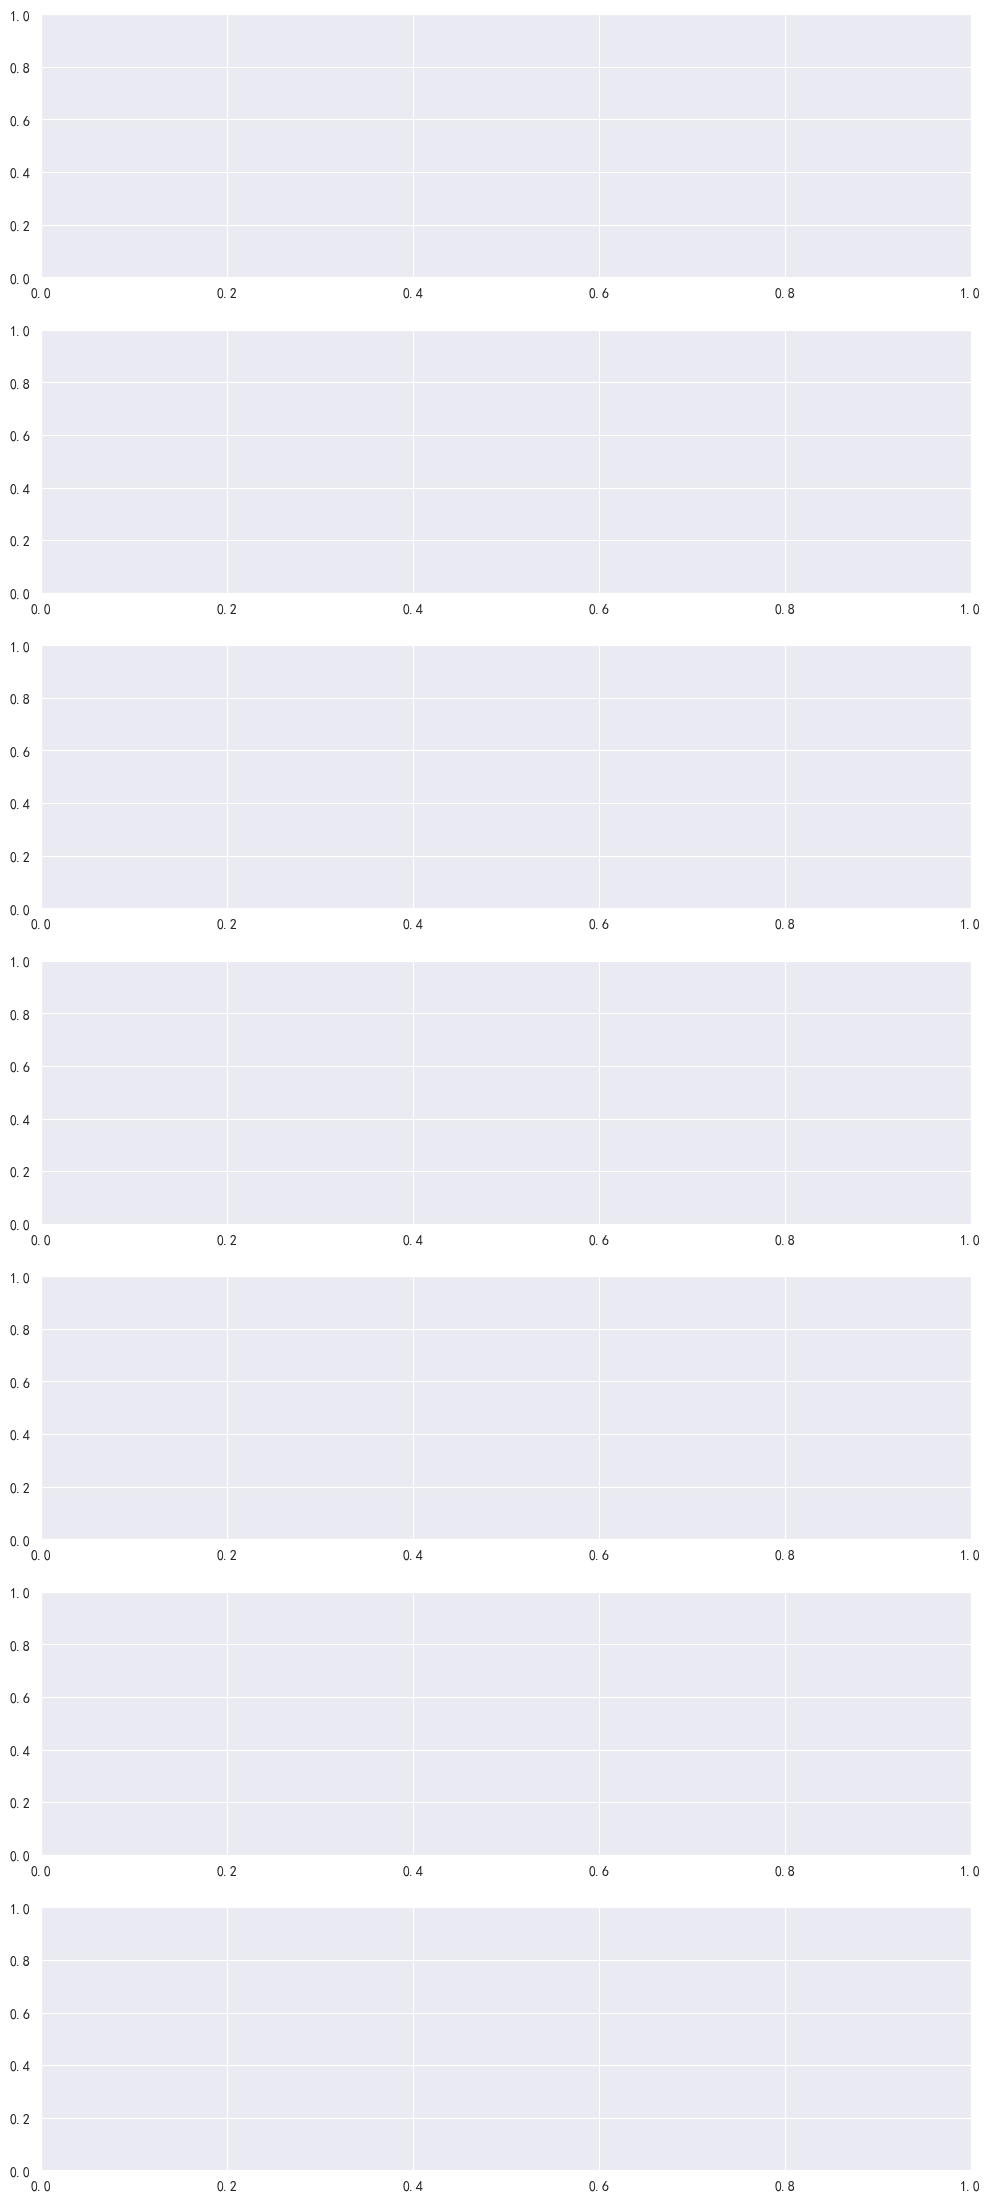

In [25]:
# Make histograms of numerical features after cleaning
# # 清洗后绘制数值特征直方图，用建模集df_model查看截断后的特征分布
cap_columns = [
    'trip_duration',
    'haversine_distance',
    'manhattan_distance',
    'euclidean_distance',
    'lat_diff',
    'lon_diff',
    'avg_speed_kmh'
]

# 创建多行1列画布：行数=需要绘图的特征数量，宽度12，每行高度4
fig, axes = plt.subplots(len(cap_columns), 1, figsize=(12, 4 * len(cap_columns)))

# 循环遍历每一个数值特征，单独绘制直方图
for idx, col in enumerate(cap_columns):
    # hist：直方图，bins=50分为50个区间，浅蓝色填充、黑色边框、透明度0.7
    axes[idx].hist(df_model[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    # 子图标题：标注当前特征、已做异常截断
    axes[idx].set_title(f'Histogram of {col} (df_model after Capping)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)# X轴：特征数值
    axes[idx].set_ylabel('Frequency')# Y轴：样本频次
    axes[idx].grid(axis='y', alpha=0.3)# 仅显示横向网格，方便看频次

plt.tight_layout()# 自动调整子图间距，避免标题重叠
plt.savefig(os.path.join(CHART_DIR, "feature_hist_all_capped.png"), bbox_inches="tight")
plt.show()

In [15]:
# Drop only truly unnecessary columns (keep datetime and location columns for feature engineering)
drop_cols = [
    'id',
    'pickup_datetime',
    'dropoff_datetime',
    'store_and_fwd_flag',
    'avg_speed_kmh',
    'trip_duration'
    ]

df_model = df_model.drop(columns = drop_cols)
df_model.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,log_trip_duration,hour,day_of_week,month,haversine_distance,manhattan_distance,euclidean_distance,lat_diff,lon_diff
67250,2,1,-73.985611,40.735943,-73.980331,40.760468,6.947937,7,2,6,2.763050,0.029804,0.025087,0.024525,0.005280
1397036,2,1,-73.978394,40.764351,-73.991623,40.749859,6.719013,12,6,4,1.959178,0.027721,0.019622,0.014492,0.013229
1021087,2,5,-73.989059,40.744389,-73.973381,40.748692,6.421622,2,6,6,1.404772,0.019981,0.016258,0.004303,0.015678
951424,2,2,-73.990326,40.731136,-73.991264,40.748917,6.766192,17,3,5,1.978660,0.018719,0.017805,0.017780,0.000938
707882,1,4,-73.789497,40.646675,-73.987137,40.759232,7.651358,17,3,5,7.823950,0.101954,0.077125,0.055935,0.050800


In [39]:
# Make label encoder for categorical features with LightGBM method
# 目标：对文本型分类特征做标签编码，转换成模型可识别数字，最后导出清洗编码完成的成品数据集

# 自动筛选所有字符串类型（object）分类特征
categorical_cols = df_model.select_dtypes(include=["object"]).columns.tolist()
# 循环对每一个分类字段做标签编码
for col in categorical_cols:
    # 初始化标签编码器
    label_encoder = LabelEncoder()

    # 先转为字符串，再完成 训练+编码转换，替换原列
    df_model[col] = label_encoder.fit_transform(df_model[col].astype(str))

# 将编码、清洗完成后的干净数据集导出为data_encoded.csv，也就是你现在在用的成品文件
df_model.to_csv('data_encoded.csv', index=False)
print(f"Encoded data saved to 'data_encoded.csv'")
# 预览编码后数据
df_model.head()

PermissionError: [Errno 13] Permission denied: 'data_encoded.csv'

In [15]:
# Prepare features for LightGBM (exclude non-predictive columns)
# 1. 筛选建模特征：剔除无预测价值的时间、原始时长、对数标签列，只保留输入特征
feature_cols = [col for col in df_model.columns if col not in 
                ['pickup_datetime', 'trip_duration', 'log_trip_duration']]
# 划分自变量X（所有用来预测的特征）、因变量y（预测目标：对数行程时长）
X = df_model[feature_cols]
y = df_model['log_trip_duration']
    
# Train LightGBM model with safe tuning
# 初始化调参后的LightGBM回归模型
model = LGBMRegressor(
    n_estimators=200,           # 决策树总数量，从100增加到200提升拟合效果
    learning_rate=0.05,         # 学习率，从0.1降低到0.05，提升模型收敛速度
    num_leaves=31,              # 树的叶子节点数，控制树的复杂度
    max_depth=7,                # 树的最大深度，限制树的深度防止过拟合
    min_data_in_leaf=20,        # 每个叶子最少20条样本，避免学习极端噪声
    lambda_l1=0.5,              # L1正则，压缩不重要特征权重，降低过拟合
    lambda_l2=0.5,              # L2正则，平滑参数权重，稳定训练
    feature_fraction=0.8,       # 每棵树随机选用80%特征，特征Bagging防过拟合
    bagging_fraction=0.8,       # 每轮迭代随机用80%样本，样本Bagging
    bagging_freq=5,             # 每5轮执行一次样本抽样Bagging
    random_state=42,            # 固定随机种子，训练结果可复现
    verbose=-1                  # 关闭训练过程冗余日志输出
)
# 使用特征X、标签y完整训练模型
model.fit(X, y)

# Display feature importance 输出特征重要性，排序查看哪些特征对预测影响最大
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)# 按重要性降序排列

print("Feature Importance:")
print(feature_importance)

# Make predictions
# 使用训练好的模型在训练集做预测
y_pred = model.predict(X)
# 计算模型拟合优度R²分数并打印，越接近1代表模型拟合效果越好
print(f"\nModel R² Score: {model.score(X, y):.4f}")

Feature Importance:
               feature  importance
6                 hour         978
5     dropoff_latitude         794
2     pickup_longitude         597
4    dropoff_longitude         587
7          day_of_week         549
3      pickup_latitude         525
13            lon_diff         452
11  euclidean_distance         425
9   haversine_distance         341
12            lat_diff         330
10  manhattan_distance         175
8                month         121
0            vendor_id          76
1      passenger_count          50

Model R² Score: 0.7740


In [16]:
# Validate model with train-test-split
# 划分训练集与验证集：80%训练，20%验证
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# 使用训练集重新训练LightGBM模型
model.fit(x_train, y_train)
# 在独立验证集上计算R²拟合分数
val_score = model.score(x_val, y_val)
print(f"Validation R² Score: {val_score:.4f}")

Validation R² Score: 0.7561


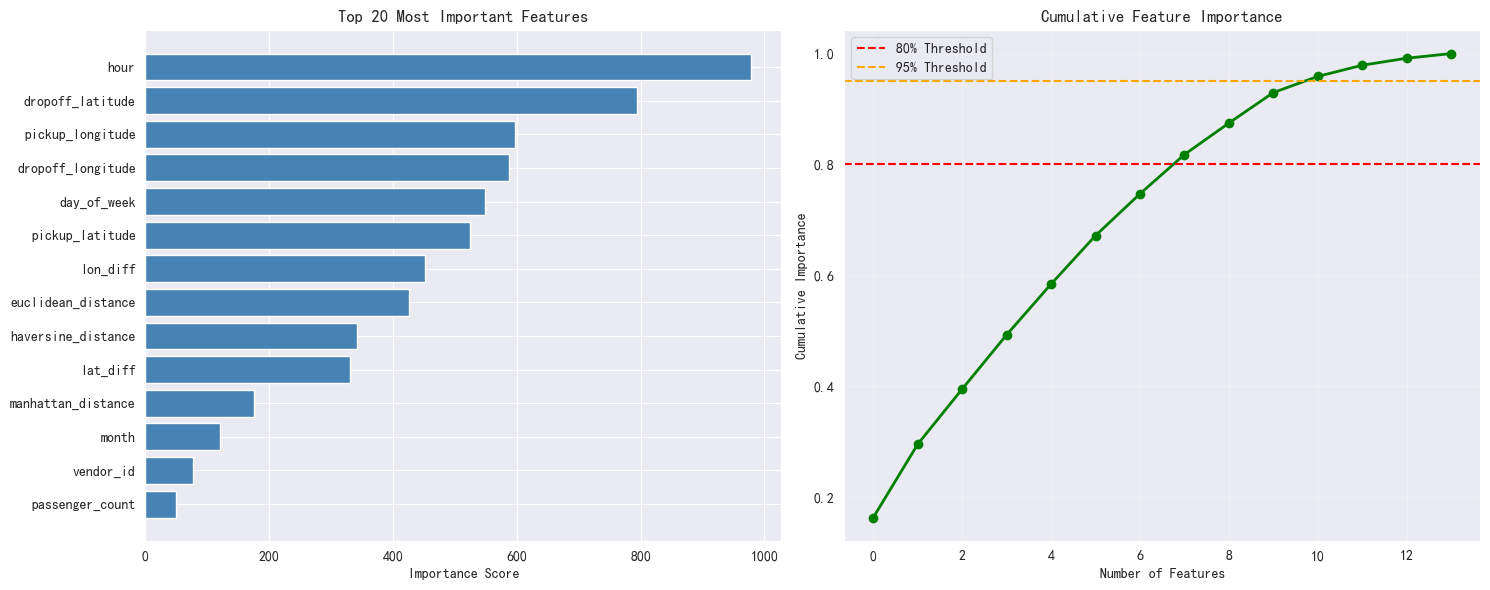


Top 10 Most Important Features:
           feature  importance
              hour         978
  dropoff_latitude         794
  pickup_longitude         597
 dropoff_longitude         587
       day_of_week         549
   pickup_latitude         525
          lon_diff         452
euclidean_distance         425
haversine_distance         341
          lat_diff         330

Total Features: 14
Features needed for 80% importance: 8
Features needed for 95% importance: 11


In [29]:
# Visualize Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot - Top 20 features 左图：横向条形图 Top20重要特征
# 取排序后前20个最重要特征
top_features = feature_importance.head(20)
axes[0].barh(top_features['feature'], top_features['importance'], color='steelblue')
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Top 20 Most Important Features')
# 反转Y轴，让最重要的特征显示在最上方
axes[0].invert_yaxis()

# Cumulative importance右图：累积特征重要性曲线
# 计算重要性累加和
cumulative_importance = np.cumsum(feature_importance['importance'].values)
# 归一化：除以总和，转为0~1区间占比
cumulative_importance = cumulative_importance / cumulative_importance[-1]
# 绘制累加曲线，绿色圆点连线
axes[1].plot(cumulative_importance, 'o-', color='green', linewidth=2)
# 80%重要性阈值红线
axes[1].axhline(y=0.8, color='red', linestyle='--', label='80% Threshold')
# 95%重要性阈值橙虚线
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% Threshold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Cumulative Feature Importance')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 自动调整子图间距，避免文字重叠
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "lgb_feature_importance_total.png"), bbox_inches="tight")
plt.show()

# Print summary
print("\nTop 10 Most Important Features:")
# 打印前10重要特征，不输出索引列
print(feature_importance.head(10).to_string(index=False))
# 全部特征总数
print(f"\nTotal Features: {len(feature_importance)}")
# 找到第一次累积占比≥0.8的特征序号，+1转为计数
print(f"Features needed for 80% importance: {np.argmax(cumulative_importance >= 0.8) + 1}")
print(f"Features needed for 95% importance: {np.argmax(cumulative_importance >= 0.95) + 1}")

In [46]:
# Cross-validation and Hyperparameter Optimization
# 1. Cross-validation with current model
print("=" * 60)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("=" * 60)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"CV Scores: {cv_scores}")
print(f"Mean CV R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 2. Grid Search for hyperparameter optimization
# For faster hyperparameter tuning, GridSearchCV is run on a smaller random sample of the dataset
print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING (GridSearchCV)")
print("=" * 60)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'max_depth': [5, 7, 10],
    'lambda_l1': [0.1, 0.5, 1.0],
    'lambda_l2': [0.1, 0.5, 1.0]
}

# Using smaller sample for faster grid search
lgbm_base = LGBMRegressor(
    n_estimators=100,
    random_state=42,
    verbose=-1
)

grid_search = GridSearchCV(
    lgbm_base,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

# Train final model with best parameters
# The final LightGBM model is trained on the full dataset using the best parameters from GridsearchCV
# This ensures the model learns from all available data
best_model = LGBMRegressor(
    n_estimators=200,
    **grid_search.best_params_,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    verbose=-1
)

best_model.fit(x_train, y_train)
best_val_score = best_model.score(x_val, y_val)

print(f"\n" + "=" * 60)
print("OPTIMIZED MODEL PERFORMANCE")
print("=" * 60)
print(f"Validation R² Score (Optimized): {best_val_score:.4f}")
print(f"Previous R² Score: {val_score:.4f}")
print(f"Improvement: {best_val_score - val_score:+.4f}")

# Additional metrics
y_pred_best = best_model.predict(x_val)
mae = mean_absolute_error(y_val, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_best))

print(f"\nValidation Metrics:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

CROSS-VALIDATION RESULTS (5-Fold)
CV Scores: [0.75192008 0.74953499 0.75510958 0.75781383 0.75285682]
Mean CV R² Score: 0.7534 (+/- 0.0028)

HYPERPARAMETER TUNING (GridSearchCV)
Fitting 3 folds for each of 243 candidates, totalling 729 fits


KeyboardInterrupt: 

In [45]:
# Convert predictions back to seconds
# np.expm1 是 np.log1p 的反向操作，还原对数变换
y_val_seconds = np.expm1(y_val)# 验证集真实对数标签 → 真实行程秒数
y_pred_seconds = np.expm1(y_pred_best)# 模型对数预测值 → 预测行程秒数

# Compute real-world error metrics
# 在真实时间单位下计算回归误差
mae_seconds = mean_absolute_error(y_val_seconds, y_pred_seconds)
rmse_seconds = np.sqrt(mean_squared_error(y_val_seconds, y_pred_seconds))

print("\nEvaluation in Original Unit (Seconds):")
print(f"MAE (seconds): {mae_seconds:.2f}")
print(f"RMSE (seconds): {rmse_seconds:.2f}")

# 秒转分钟，更贴合日常理解打车时长
print(f"\nMAE (minutes): {mae_seconds/60:.2f}")
print(f"RMSE (minutes): {rmse_seconds/60:.2f}")

NameError: name 'y_pred_best' is not defined

In [47]:
# Calculate absolute error in seconds
# 1. 复制验证集特征表，用来拼接真实时长、预测时长、误差字段
df_val = x_val.copy()
# 把逆变换后的真实行程秒数存入新列
df_val['actual_seconds'] = y_val_seconds
# 把模型预测行程秒数存入新列
df_val['predicted_seconds'] = y_pred_seconds
# 计算单条订单绝对误差：|真实时长 - 预测时长|
df_val['absolute_error'] = abs(df_val['actual_seconds'] - df_val['predicted_seconds'])

# Define unusual trips (example: error > 2 * MAE)
# 设定异常订单判定阈值：误差超过2倍平均绝对误差MAE
threshold = 2 * mae_seconds
# 生成布尔标记列：True=误差超大、预测严重失准的异常订单
df_val['is_unusual'] = df_val['absolute_error'] > threshold

# 统计并打印异常订单总数量
print(f"Number of unusual trips: {df_val['is_unusual'].sum()}")

NameError: name 'y_pred_seconds' is not defined

In [1]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 选取刻画用户出行行为的核心特征
cluster_features = df_model[["haversine_distance", "trip_duration", "hour"]]
# 聚类前标准化（消除量纲影响）
scaler = StandardScaler()
feature_scaled = scaler.fit_transform(cluster_features)

# 绘制肘部法则图，验证最优聚类数量k=3
inertia_list = []
k_range = range(1, 10)
for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=42)
    km_temp.fit(feature_scaled)
    inertia_list.append(km_temp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia_list, marker="o", c="#2E86AB")
plt.xlabel("聚类数量K")
plt.ylabel("簇内误差平方和Inertia")
plt.title("K-Means肘部法则：确定最优分群数量")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(CHART_DIR, "kmeans_elbow.png"), bbox_inches="tight")
plt.show()

# 正式执行K-Means分群，固定随机种子保证结果可复现
kmeans_model = KMeans(n_clusters=3, random_state=42)
df_model["user_group"] = kmeans_model.fit_predict(feature_scaled)

# 输出每一类用户的平均出行指标，用于画像定义
user_profile_result = df_model.groupby("user_group")[["haversine_distance", "trip_duration", "hour"]].mean()
print("三类乘客出行特征均值：")
print(user_profile_result)

# 绘制各群体订单数量分布柱状图
plt.figure(figsize=(10, 5))
sns.countplot(x="user_group", data=df_model, palette="Set2")
plt.title("三类出行用户订单数量分布")
plt.xlabel("用户群体编号")
plt.ylabel("订单条数")
plt.savefig(os.path.join(CHART_DIR, "user_group_dist.png"), bbox_inches="tight")
plt.show()

NameError: name 'df_model' is not defined